# Classification metrics

Code repository for the book:

[Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from imblearn.datasets import fetch_datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix_at_thresholds

## Load data

In [2]:
# Load dataset from imbalanced learn.

def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test

In [3]:
X_train, X_test, y_train, y_test = load_dataset("protein_homo")

print(f"Target mean: {np.mean(y_train):.4f}")

Target mean: 0.0087


## Train Gradient Boosting Machine

In [4]:
gbm = GradientBoostingClassifier(random_state=0)
gbm.fit(X_train, y_train)

y_probs = gbm.predict_proba(X_test)[:,1]

## Confusion matrix

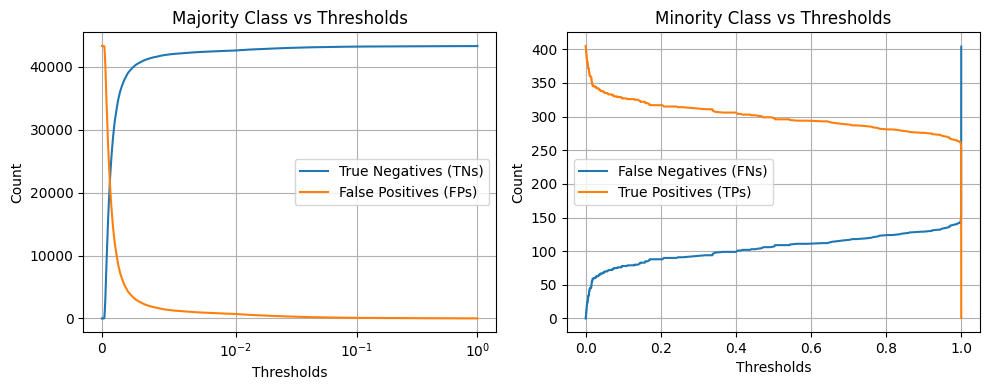

In [5]:
tns, fps, fns, tps, threshold = confusion_matrix_at_thresholds(y_test, y_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left plot: TNs and FPs
ax1.plot(threshold, tns, label="True Negatives (TNs)")
ax1.plot(threshold, fps, label="False Positives (FPs)")
ax1.set_xlabel("Thresholds")
ax1.set_ylabel("Count")
ax1.set_title("Majority Class vs Thresholds")
ax1.legend()
ax1.grid()
ax1.set_xscale("symlog", linthresh=0.01)

# Right plot: FNs and TPs
ax2.plot(threshold, fns, label="False Negatives (FNs)")
ax2.plot(threshold, tps, label="True Positives (TPs)")
ax2.set_xlabel("Thresholds")
ax2.set_ylabel("Count")
ax2.set_title("Minority Class vs Thresholds")
ax2.legend()
ax2.grid()
# ax2.set_xscale("symlog", linthresh=0.01)

plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch2/ch2-fig3.png", dpi=300, bbox_inches="tight")
plt.show()

## Threshold dependent metrics

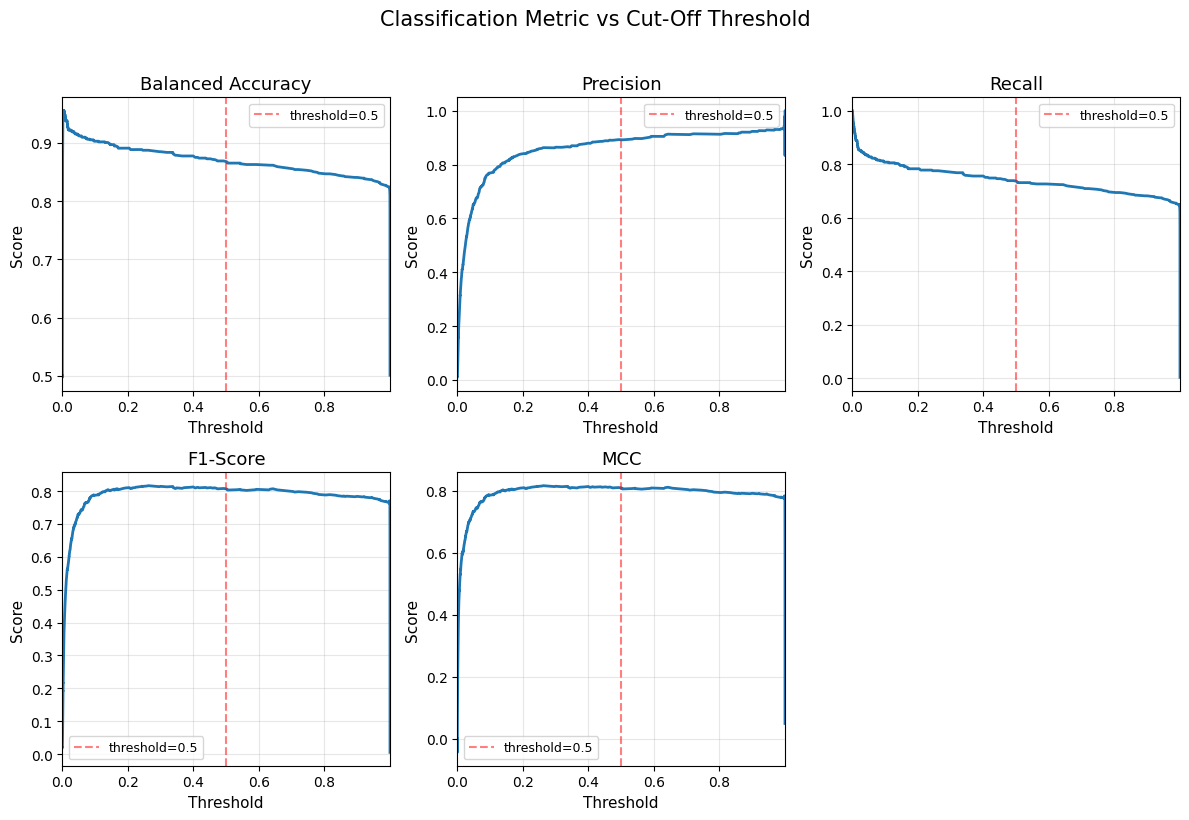

In [6]:
from sklearn.metrics import (
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    matthews_corrcoef,
)

thresholds = np.sort(np.unique(y_probs))

metrics = {
    "Balanced Accuracy": [],
    "Precision":         [],
    "Recall":            [],
    "F1-Score":          [],
    "MCC":               [],
}

for thresh in thresholds:
    preds = (y_probs >= thresh).astype(int)
    metrics["Balanced Accuracy"].append(balanced_accuracy_score(y_test, preds))
    metrics["Precision"].append(precision_score(y_test, preds, zero_division=0))
    metrics["Recall"].append(recall_score(y_test, preds, zero_division=0))
    metrics["F1-Score"].append(f1_score(y_test, preds, zero_division=0))
    metrics["MCC"].append(matthews_corrcoef(y_test, preds))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
top = axes[0, :]
bottom = axes[1, :]
bottom[2].axis('off')
plot_axes = [top[0], top[1], top[2], bottom[0], bottom[1]]

for ax, (name, vals) in zip(plot_axes, metrics.items()):
    ax.plot(thresholds, vals, linewidth=2)
    ax.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='threshold=0.5')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_xlim(thresholds.min(), thresholds.max())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Classification Metric vs Cut-Off Threshold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch2/ch2-fig4.png", dpi=300, bbox_inches="tight")
plt.show()

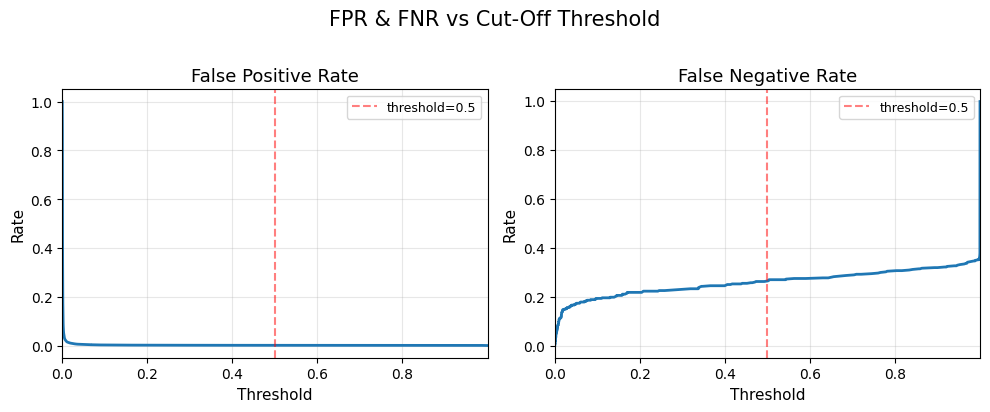

In [7]:
tns, fps, fns, tps, thresholds = confusion_matrix_at_thresholds(y_test, y_probs)

metrics = {
    "False Positive Rate": [fp / (fp + tn) if (fp + tn) > 0 else 0 for tn, fp, fn, tp in zip(tns, fps, fns, tps)],
    "False Negative Rate": [fn / (fn + tp) if (fn + tp) > 0 else 0 for tn, fp, fn, tp in zip(tns, fps, fns, tps)],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, vals) in zip(axes, metrics.items()):
    ax.plot(thresholds, vals, linewidth=2)
    ax.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='threshold=0.5')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Rate", fontsize=11)
    ax.set_xlim(thresholds.min(), thresholds.max())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("FPR & FNR vs Cut-Off Threshold", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()